# RCPSPTT Setup-time Benchmark Results - 9.4.2026

Analysis of IBM CPO vs OptalCP using the **setup-time formulation** (`no_overlap` with transition matrices) on RCPSP with Transfer Times instances (j30, j60, j90, j120).

Data are from https://www2.informatik.uni-osnabrueck.de/kombopt/data/rcpsp/
Instances of RCPSP with transfer times, used in Poppenborg, Knust [2016]:

**Setup:** 120s time limit, 8 workers per instance.

Setup-time formulace zlepšuje řešitelnost oproti flow formulaci. Zatímco flow formulace s OptalCP nenašla žádné řešení na j120 a pouze 6 % na j90, setup-time formulace dosahuje 100% řešitelnost (CPO) resp. 90 % (OptalCP) i na největších j120 instancích. Na j30–j90 obě setup-time varianty řeší 100 % instancí.

Srovnání solverů (setup-time)
OptalCP najde lepší řešení, CPO je spolehlivější:

Na 198 společně vyřešených instancích OptalCP zvítězil na **96 (48 %), CPO na 51 (26 %), shoda na 51 (26 %)**.
CPO vyřešil všech 204 instancí (100 %), OptalCP 198 (97 %) — na j120 nenašel řešení u 6 instancí.
Optimalitu dokázal OptalCP na 31 instancích (j30: 10, j60: 9, j90: 12), CPO na 27 (j30: 8, j60: 9, j90: 10). Na j120 nedokázal optimum nikdo.

Charakter solverů se zachoval:
CPO najde první řešení bleskově (BST 0.02–0.09 s), pak zbytek limitu vylepšuje.
OptalCP potřebuje déle na první řešení (BST 13–39 s), ale když už řeší, často najde lepší výsledek.
Setup-time vs Flow (head-to-head)
Na 171 instancích, kde obě formulace našly řešení:

Setup lepší na 123 instancích (72 %), průměrné zlepšení 24.7 %, max 89.4 %.
Flow lepší pouze na 3 instancích (1.8 %), a to jen o 1.7 % v průměru.
S rostoucí velikostí je převaha setup-time stále výraznější: na j120 vyhrál setup na všech 40 společných instancích.
Nové nejlepší výsledky (vs. Poppenborg & Knust 2016)
Setup-time formulace překonala referenční upper bounds z tabu search na 69 instancích:

j30: 5 nových best, j60: 15, j90: 19, j120: 30.
Nejlepší zlepšení: 8.3 % (j1208_a: 133 vs ref 145).
Naprostou většinu nových best nalezl OptalCP setup.
Na druhou stranu, na 53 instancích jsou naše výsledky horší než referenční tabu search, to je očekávatelné, protože tabu search je specializovaná heuristika, zatímco CP solvery s 120s limitem nemusí stihnout dostatečně prohledat prostor.

In [1]:
import json
import pandas as pd
from pathlib import Path

DATA_DIR = Path(".")
SOLVERS = ["optal_setup", "cpo_setup"]
SOLVER_LABELS = {"optal_setup": "OptalCP", "cpo_setup": "CPO"}
SETS = ["j30", "j60", "j90", "j120"]

# Load all results into a single DataFrame
rows = []
for solver in ["optal", "cpo"]:
    for s in SETS:
        fp = DATA_DIR / f"{solver}_{s}.json"
        if fp.exists():
            with open(fp) as f:
                for r in json.load(f):
                    r["set"] = s
                    rows.append(r)

df = pd.DataFrame(rows)
df["set"] = pd.Categorical(df["set"], categories=SETS, ordered=True)
df["solver_label"] = df["solver"].map(SOLVER_LABELS)
print(f"Loaded {len(df)} results ({df['solver'].nunique()} solvers × {df['set'].nunique()} sets)")
print(f"Solver names in data: {df['solver'].unique().tolist()}")

Loaded 408 results (2 solvers × 4 sets)
Solver names in data: ['optal_setup', 'cpo_setup']


## State counts per solver and set

In [2]:
# Pivot: rows = (set, solver), columns = state
state_table = (df.groupby(["set", "solver", "state"], observed=False)
               .size()
               .unstack(fill_value=0)
               .reindex(columns=["Optimal", "Feasible", "NoSolution", "Error"], fill_value=0))

state_table["Total"] = state_table.sum(axis=1)
state_table["Solved"] = state_table["Optimal"] + state_table["Feasible"]
state_table["Solved %"] = (state_table["Solved"] / state_table["Total"] * 100).round(1)

state_table

state             Optimal  Feasible  NoSolution  Error  Total  Solved  \
set  solver                                                             
j30  cpo_setup          8        40           0      0     48      48   
     optal_setup       10        38           0      0     48      48   
j60  cpo_setup          9        39           0      0     48      48   
     optal_setup        9        39           0      0     48      48   
j90  cpo_setup         10        38           0      0     48      48   
     optal_setup       12        36           0      0     48      48   
j120 cpo_setup          0        60           0      0     60      60   
     optal_setup        0        54           6      0     60      54   

state             Solved %  
set  solver                 
j30  cpo_setup       100.0  
     optal_setup     100.0  
j60  cpo_setup       100.0  
     optal_setup     100.0  
j90  cpo_setup       100.0  
     optal_setup     100.0  
j120 cpo_setup       100.0  
     optal_setup      90.0

## Solved instances by solver and set

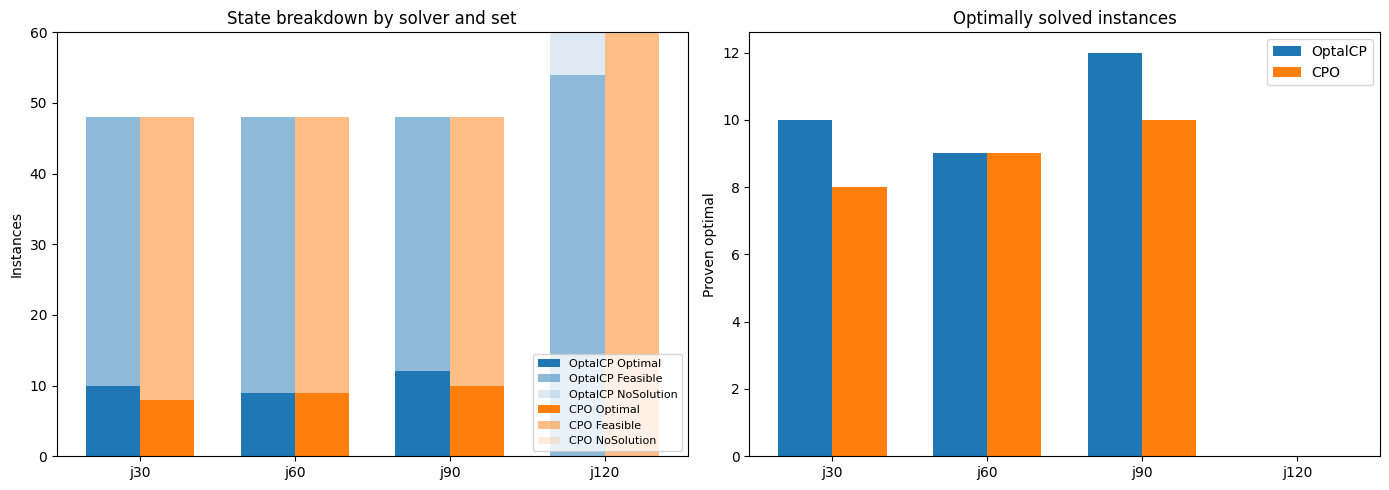

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(SETS))
width = 0.35

# --- Left: stacked bar chart (Optimal / Feasible / NoSolution) ---
ax = axes[0]
for i, solver in enumerate(SOLVERS):
    sub = df[df["solver"] == solver]
    optimal = [len(sub[(sub["set"] == s) & (sub["state"] == "Optimal")]) for s in SETS]
    feasible = [len(sub[(sub["set"] == s) & (sub["state"] == "Feasible")]) for s in SETS]
    nosol = [len(sub[(sub["set"] == s) & (sub["state"] == "NoSolution")]) for s in SETS]
    label = SOLVER_LABELS[solver]

    offset = (i - 0.5) * width
    ax.bar(x + offset, optimal, width, label=f"{label} Optimal", color=f"C{i}", alpha=1.0)
    ax.bar(x + offset, feasible, width, bottom=optimal, label=f"{label} Feasible",
           color=f"C{i}", alpha=0.5)
    ax.bar(x + offset, nosol, width,
           bottom=[o + f for o, f in zip(optimal, feasible)],
           label=f"{label} NoSolution", color=f"C{i}", alpha=0.15)

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Instances")
ax.set_title("State breakdown by solver and set")
ax.legend(fontsize=8)

# --- Right: Optimal count comparison ---
ax = axes[1]
for i, solver in enumerate(SOLVERS):
    sub = df[(df["solver"] == solver) & (df["state"] == "Optimal")]
    counts = [len(sub[sub["set"] == s]) for s in SETS]
    ax.bar(x + (i - 0.5) * width, counts, width, label=SOLVER_LABELS[solver], color=f"C{i}")

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Proven optimal")
ax.set_title("Optimally solved instances")
ax.legend()

plt.tight_layout()
plt.show()

## Runtime and best solution time statistics

In [4]:
# Only look at instances that found at least a feasible solution
solved = df[df["state"].isin(["Optimal", "Feasible"])].copy()

time_stats = (solved.groupby(["set", "solver"], observed=False)
              .agg(
                  count=("instance", "size"),
                  avg_duration=("duration", "mean"),
                  max_duration=("duration", "max"),
                  avg_bst=("best_solution_time", "mean"),
                  median_bst=("best_solution_time", "median"),
                  max_bst=("best_solution_time", "max"),
                  avg_build=("build_time", "mean"),
              )
              .round(3))

time_stats

count  avg_duration  max_duration  avg_bst  median_bst  \
set  solver                                                                
j30  cpo_setup       48       102.646       120.164    0.020       0.020   
     optal_setup     48        98.092       120.061   13.967       0.606   
j60  cpo_setup       48       102.750       120.266    0.042       0.040   
     optal_setup     48        98.190       120.138   12.693       2.376   
j90  cpo_setup       48       101.454       120.726    0.087       0.055   
     optal_setup     48        91.781       120.332   27.233      13.193   
j120 cpo_setup       60       120.228       120.689    0.080       0.065   
     optal_setup     54       120.131       120.399   38.502      26.772   

                  max_bst  avg_build  
set  solver                           
j30  cpo_setup      0.050      0.016  
     optal_setup   96.498      0.014  
j60  cpo_setup      0.150      0.054  
     optal_setup   98.518      0.043  
j90  cpo_setup      0.290      0.088  
     optal_setup  117.006      0.100  
j120 cpo_setup      0.250      0.092  
     optal_setup  113.759      0.117

## Objective comparison on common instances

In [5]:
# Pivot to compare objectives side-by-side
pivot = df.pivot_table(index=["set", "instance"], columns="solver",
                       values=["objective", "state", "duration", "best_solution_time"],
                       aggfunc="first")

# Instances where both solvers found a solution
both_solved = pivot.dropna(subset=[("objective", "optal_setup"), ("objective", "cpo_setup")])

obj_optal = both_solved[("objective", "optal_setup")]
obj_cpo = both_solved[("objective", "cpo_setup")]

optal_wins = (obj_optal < obj_cpo).sum()
cpo_wins = (obj_cpo < obj_optal).sum()
ties = (obj_optal == obj_cpo).sum()

print(f"Instances where BOTH solvers found a solution: {len(both_solved)}")
print(f"  OptalCP better objective: {optal_wins}")
print(f"  CPO better objective:     {cpo_wins}")
print(f"  Same objective:           {ties}")
print()

# Instances solved by only one solver
optal_only = df[(df["solver"] == "optal_setup") & (df["objective"].notna())].set_index("instance")
cpo_only = df[(df["solver"] == "cpo_setup") & (df["objective"].notna())].set_index("instance")

only_optal = set(optal_only.index) - set(cpo_only.index)
only_cpo = set(cpo_only.index) - set(optal_only.index)

print(f"Solved ONLY by OptalCP: {len(only_optal)}")
print(f"Solved ONLY by CPO:     {len(only_cpo)}")

Instances where BOTH solvers found a solution: 198
  OptalCP better objective: 96
  CPO better objective:     51
  Same objective:           51

Solved ONLY by OptalCP: 0
Solved ONLY by CPO:     6


/tmp/ipykernel_1097035/794443189.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index=["set", "instance"], columns="solver",


## Best solution time distribution (solved instances only)

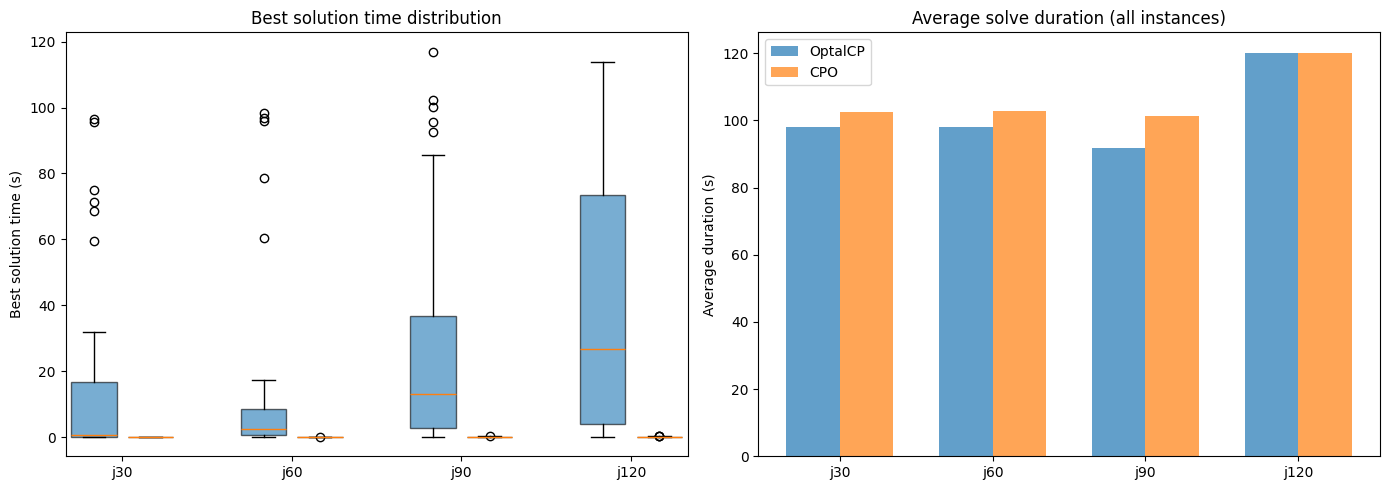

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Best solution time by set (box plot) ---
ax = axes[0]
positions = []
data_to_plot = []
colors = []
color_map = {"optal_setup": "C0", "cpo_setup": "C1"}

for j, s in enumerate(SETS):
    for k, solver in enumerate(SOLVERS):
        sub = solved[(solved["set"] == s) & (solved["solver"] == solver)]
        bst = sub["best_solution_time"].dropna()
        if len(bst) > 0:
            data_to_plot.append(bst.values)
            positions.append(j * 3 + k)
            colors.append(color_map[solver])

if data_to_plot:
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.8, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

ax.set_xticks([j * 3 + 0.5 for j in range(len(SETS))])
ax.set_xticklabels(SETS)
ax.set_ylabel("Best solution time (s)")
ax.set_title("Best solution time distribution")

# --- Right: Duration (total solve time) by set ---
ax = axes[1]
for i, solver in enumerate(SOLVERS):
    sub = df[df["solver"] == solver]
    avg_dur = [sub[sub["set"] == s]["duration"].mean() for s in SETS]
    ax.bar(x + (i - 0.5) * width, avg_dur, width, label=SOLVER_LABELS[solver], color=f"C{i}", alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Average duration (s)")
ax.set_title("Average solve duration (all instances)")
ax.legend()

plt.tight_layout()
plt.show()

## Detailed per-set summary

In [7]:
for s in SETS:
    sub = df[df["set"] == s]
    n_instances = sub["instance"].nunique()
    print(f"\n{'='*60}")
    print(f"  {s.upper()} — {n_instances} instances")
    print(f"{'='*60}")

    for solver in SOLVERS:
        ss = sub[sub["solver"] == solver]
        n_opt = len(ss[ss["state"] == "Optimal"])
        n_feas = len(ss[ss["state"] == "Feasible"])
        n_nosol = len(ss[ss["state"] == "NoSolution"])

        print(f"\n  {SOLVER_LABELS[solver]} ({solver}):")
        print(f"    Optimal:    {n_opt}/{len(ss)} ({n_opt/len(ss)*100:.0f}%)" if len(ss) > 0 else "")
        print(f"    Feasible:   {n_feas}/{len(ss)} ({n_feas/len(ss)*100:.0f}%)" if len(ss) > 0 else "")
        print(f"    NoSolution: {n_nosol}/{len(ss)} ({n_nosol/len(ss)*100:.0f}%)" if len(ss) > 0 else "")

        ss_solved = ss[ss["state"].isin(["Optimal", "Feasible"])]
        if len(ss_solved) > 0:
            bst = ss_solved["best_solution_time"].dropna()
            print(f"    Avg best solution time: {bst.mean():.3f}s" if len(bst) > 0 else "")
            print(f"    Avg total duration:     {ss_solved['duration'].mean():.3f}s")
            print(f"    Avg build time:         {ss_solved['build_time'].mean():.3f}s")


  J30 — 48 instances

  OptalCP (optal_setup):
    Optimal:    10/48 (21%)
    Feasible:   38/48 (79%)
    NoSolution: 0/48 (0%)
    Avg best solution time: 13.967s
    Avg total duration:     98.092s
    Avg build time:         0.014s

  CPO (cpo_setup):
    Optimal:    8/48 (17%)
    Feasible:   40/48 (83%)
    NoSolution: 0/48 (0%)
    Avg best solution time: 0.020s
    Avg total duration:     102.646s
    Avg build time:         0.016s

  J60 — 48 instances

  OptalCP (optal_setup):
    Optimal:    9/48 (19%)
    Feasible:   39/48 (81%)
    NoSolution: 0/48 (0%)
    Avg best solution time: 12.693s
    Avg total duration:     98.190s
    Avg build time:         0.043s

  CPO (cpo_setup):
    Optimal:    9/48 (19%)
    Feasible:   39/48 (81%)
    NoSolution: 0/48 (0%)
    Avg best solution time: 0.043s
    Avg total duration:     102.750s
    Avg build time:         0.054s

  J90 — 48 instances

  OptalCP (optal_setup):
    Optimal:    12/48 (25%)
    Feasible:   36/48 (75%)
    NoS

## Objective scatter plot (OptalCP vs CPO)

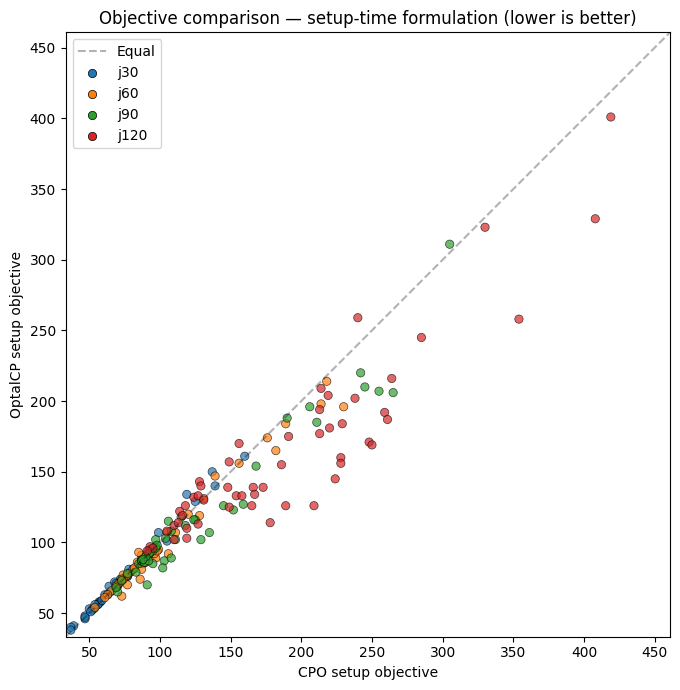

In [8]:
if len(both_solved) > 0:
    fig, ax = plt.subplots(figsize=(7, 7))

    obj_o = both_solved[("objective", "optal_setup")].values
    obj_c = both_solved[("objective", "cpo_setup")].values

    set_colors = {"j30": "C0", "j60": "C1", "j90": "C2", "j120": "C3"}
    colors = [set_colors[s] for s, _ in both_solved.index]

    ax.scatter(obj_c, obj_o, c=colors, alpha=0.7, edgecolors="k", linewidths=0.5)

    lo = min(min(obj_o), min(obj_c)) * 0.9
    hi = max(max(obj_o), max(obj_c)) * 1.1
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, label="Equal")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("CPO setup objective")
    ax.set_ylabel("OptalCP setup objective")
    ax.set_title("Objective comparison — setup-time formulation (lower is better)")
    ax.set_aspect("equal")

    for s, c in set_colors.items():
        ax.scatter([], [], c=c, label=s, edgecolors="k", linewidths=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No instances solved by both solvers — cannot create scatter plot.")

## Unsolved instances

In [9]:
# Instances where NEITHER solver found any solution
no_sol_both = (df[df["state"] == "NoSolution"]
               .groupby(["set", "instance"], observed=False)
               .size()
               .reset_index(name="n_solvers_failed"))
unsolved_by_both = no_sol_both[no_sol_both["n_solvers_failed"] == len(SOLVERS)]

print(f"Instances unsolved by BOTH solvers: {len(unsolved_by_both)}")
print(f"  Per set: {unsolved_by_both.groupby('set', observed=False).size().to_dict()}")
print()

any_nosol = df[df["state"] == "NoSolution"].groupby("set", observed=False).size()
print("NoSolution counts (total across solvers):")
print(any_nosol.to_string())

Instances unsolved by BOTH solvers: 0
  Per set: {'j30': 0, 'j60': 0, 'j90': 0, 'j120': 0}

NoSolution counts (total across solvers):
set
j30     0
j60     0
j90     0
j120    6


## Summary table

In [10]:
summary_rows = []
for solver in SOLVERS:
    for s in SETS:
        sub = df[(df["solver"] == solver) & (df["set"] == s)]
        n = len(sub)
        if n == 0:
            continue
        n_opt = len(sub[sub["state"] == "Optimal"])
        n_feas = len(sub[sub["state"] == "Feasible"])
        n_nosol = len(sub[sub["state"] == "NoSolution"])
        ss = sub[sub["state"].isin(["Optimal", "Feasible"])]
        bst = ss["best_solution_time"].dropna()

        summary_rows.append({
            "Solver": SOLVER_LABELS[solver],
            "Set": s,
            "Total": n,
            "Optimal": n_opt,
            "Feasible": n_feas,
            "NoSolution": n_nosol,
            "Solved %": f"{(n_opt + n_feas) / n * 100:.0f}%",
            "Avg BST (s)": f"{bst.mean():.2f}" if len(bst) > 0 else "—",
            "Avg Duration (s)": f"{ss['duration'].mean():.1f}" if len(ss) > 0 else "—",
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.style.hide(axis="index")

Solver,Set,Total,Optimal,Feasible,NoSolution,Solved %,Avg BST (s),Avg Duration (s)
OptalCP,j30,48,10,38,0,100%,13.97,98.1
OptalCP,j60,48,9,39,0,100%,12.69,98.2
OptalCP,j90,48,12,36,0,100%,27.23,91.8
OptalCP,j120,60,0,54,6,90%,38.50,120.1
CPO,j30,48,8,40,0,100%,0.02,102.6
CPO,j60,48,9,39,0,100%,0.04,102.8
CPO,j90,48,10,38,0,100%,0.09,101.5
CPO,j120,60,0,60,0,100%,0.08,120.2


---

# Setup-times vs Flows vs Reference (Poppenborg & Knust)

Comparison of **setup-time formulation** (this folder) against:
1. **Flow formulation** results from `../8.4.2026_flows/`
2. **Reference upper bounds** from Poppenborg & Knust (2016) tabu search — `../../data/rcpsp_tt_{30,60,90,120}.txt`

All experiments: 120s time limit, 8 workers.

In [11]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

SETUP_DIR = Path(".")
FLOW_DIR = Path("../8.4.2026_flows")
REF_DIR = Path("../../data")
SETS = ["j30", "j60", "j90", "j120"]

# --- Load reference values (Poppenborg & Knust) ---
refs = {}
for size in [30, 60, 90, 120]:
    with open(REF_DIR / f"rcpsp_tt_{size}.txt") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("Instance") or line.startswith("---"):
                continue
            parts = line.split()
            if len(parts) >= 3:
                try:
                    refs[parts[0]] = {"lb": int(parts[1]), "ub": int(parts[2])}
                except ValueError:
                    continue

# --- Load all solver results ---
rows = []
for solver_prefix in ["cpo", "optal"]:
    for s in SETS:
        # Flow
        fp = FLOW_DIR / f"{solver_prefix}_{s}.json"
        if fp.exists():
            with open(fp) as f:
                for r in json.load(f):
                    r["set"] = s
                    r["formulation"] = "flow"
                    r["solver_form"] = f"{r['solver']}"
                    rows.append(r)
        # Setup
        fp = SETUP_DIR / f"{solver_prefix}_{s}.json"
        if fp.exists():
            with open(fp) as f:
                for r in json.load(f):
                    r["set"] = s
                    r["formulation"] = "setup"
                    r["solver_form"] = f"{r['solver']}"
                    rows.append(r)

all_df = pd.DataFrame(rows)
all_df["set"] = pd.Categorical(all_df["set"], categories=SETS, ordered=True)

# Add reference columns
all_df["ref_lb"] = all_df["instance"].map(lambda x: refs.get(x, {}).get("lb"))
all_df["ref_ub"] = all_df["instance"].map(lambda x: refs.get(x, {}).get("ub"))

print(f"Loaded {len(all_df)} total results")
print(f"  Flow:  {len(all_df[all_df['formulation']=='flow'])} ({all_df[all_df['formulation']=='flow']['solver_form'].unique()})")
print(f"  Setup: {len(all_df[all_df['formulation']=='setup'])} ({all_df[all_df['formulation']=='setup']['solver_form'].unique()})")
print(f"  Reference: {len(refs)} instances with LB/UB")

Loaded 816 total results
  Flow:  408 (['cpo' 'optal'])
  Setup: 408 (['cpo_setup' 'optal_setup'])
  Reference: 408 instances with LB/UB


## State comparison: Setup-times vs Flows (all 4 solvers)

In [12]:
state_cmp = (all_df.groupby(["set", "solver_form", "state"], observed=False)
             .size()
             .unstack(fill_value=0)
             .reindex(columns=["Optimal", "Feasible", "NoSolution", "Error"], fill_value=0))

state_cmp["Total"] = state_cmp.sum(axis=1)
state_cmp["Solved"] = state_cmp["Optimal"] + state_cmp["Feasible"]
state_cmp["Solved %"] = (state_cmp["Solved"] / state_cmp["Total"] * 100).round(1)
state_cmp

state             Optimal  Feasible  NoSolution  Error  Total  Solved  \
set  solver_form                                                        
j30  cpo               16        29           3      0     48      45   
     cpo_setup          8        40           0      0     48      48   
     optal             19         1          28      0     48      20   
     optal_setup       10        38           0      0     48      48   
j60  cpo               12        30           6      0     48      42   
     cpo_setup          9        39           0      0     48      48   
     optal             10         0          38      0     48      10   
     optal_setup        9        39           0      0     48      48   
j90  cpo                6        38           4      0     48      44   
     cpo_setup         10        38           0      0     48      48   
     optal              3         0          45      0     48       3   
     optal_setup       12        36           0      0     48      48   
j120 cpo                0        40          20      0     60      40   
     cpo_setup          0        60           0      0     60      60   
     optal              0         0          60      0     60       0   
     optal_setup        0        54           6      0     60      54   

state             Solved %  
set  solver_form            
j30  cpo              93.8  
     cpo_setup       100.0  
     optal            41.7  
     optal_setup     100.0  
j60  cpo              87.5  
     cpo_setup       100.0  
     optal            20.8  
     optal_setup     100.0  
j90  cpo              91.7  
     cpo_setup       100.0  
     optal             6.2  
     optal_setup     100.0  
j120 cpo              66.7  
     cpo_setup       100.0  
     optal             0.0  
     optal_setup      90.0

## Solved instances: Setup-times vs Flows (bar chart)

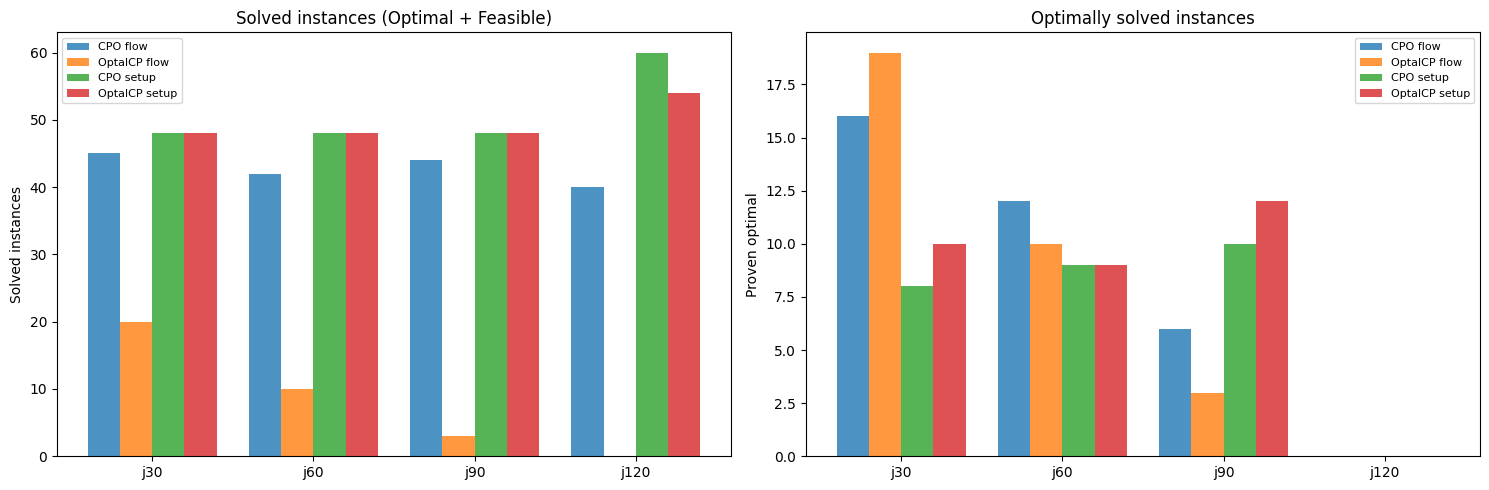

In [13]:
solver_forms = ["cpo", "optal", "cpo_setup", "optal_setup"]
solver_labels = ["CPO flow", "OptalCP flow", "CPO setup", "OptalCP setup"]
colors_sf = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(SETS))
width = 0.2

# Left: Solved count (Optimal + Feasible)
ax = axes[0]
for i, (sf, label, color) in enumerate(zip(solver_forms, solver_labels, colors_sf)):
    counts = []
    for s in SETS:
        sub = all_df[(all_df["solver_form"] == sf) & (all_df["set"] == s)]
        counts.append(len(sub[sub["state"].isin(["Optimal", "Feasible"])]))
    ax.bar(x + (i - 1.5) * width, counts, width, label=label, color=color, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Solved instances")
ax.set_title("Solved instances (Optimal + Feasible)")
ax.legend(fontsize=8)

# Right: Optimal count
ax = axes[1]
for i, (sf, label, color) in enumerate(zip(solver_forms, solver_labels, colors_sf)):
    counts = []
    for s in SETS:
        sub = all_df[(all_df["solver_form"] == sf) & (all_df["set"] == s)]
        counts.append(len(sub[sub["state"] == "Optimal"]))
    ax.bar(x + (i - 1.5) * width, counts, width, label=label, color=color, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(SETS)
ax.set_ylabel("Proven optimal")
ax.set_title("Optimally solved instances")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Best objective per instance (across all 4 solvers) vs Reference

In [14]:
# Build per-instance comparison: best obj from each formulation + reference
instances = sorted(all_df["instance"].unique())

comp_rows = []
for inst in instances:
    sub = all_df[all_df["instance"] == inst]
    s = sub["set"].iloc[0]
    ref = refs.get(inst, {})

    row = {"instance": inst, "set": s, "ref_lb": ref.get("lb"), "ref_ub": ref.get("ub")}

    for sf in solver_forms:
        ss = sub[sub["solver_form"] == sf]
        if len(ss) > 0 and ss.iloc[0]["objective"] is not None and ss.iloc[0]["objective"] > 0:
            row[sf] = int(ss.iloc[0]["objective"])
            row[f"{sf}_state"] = ss.iloc[0]["state"]
        else:
            row[sf] = None
            row[f"{sf}_state"] = ss.iloc[0]["state"] if len(ss) > 0 else None

    # Best across all solvers
    vals = [row[sf] for sf in solver_forms if row.get(sf) is not None]
    row["best_all"] = min(vals) if vals else None

    # Best per formulation
    flow_vals = [row[sf] for sf in ["cpo", "optal"] if row.get(sf) is not None]
    setup_vals = [row[sf] for sf in ["cpo_setup", "optal_setup"] if row.get(sf) is not None]
    row["best_flow"] = min(flow_vals) if flow_vals else None
    row["best_setup"] = min(setup_vals) if setup_vals else None

    comp_rows.append(row)

comp = pd.DataFrame(comp_rows)
comp["set"] = pd.Categorical(comp["set"], categories=SETS, ordered=True)

print(f"Comparison table: {len(comp)} instances")
comp[["instance", "set", "ref_lb", "ref_ub", "cpo", "optal", "cpo_setup", "optal_setup", "best_flow", "best_setup", "best_all"]].head(10)

Comparison table: 204 instances


,instance,set,ref_lb,ref_ub,cpo,optal,cpo_setup,optal_setup,best_flow,best_setup,best_all
0,j12010_a,j120,79,107,178.0,NaN,119,103.0,178.0,103,103
1,j12011_a,j120,109,368,NaN,NaN,419,401.0,NaN,401,401
2,j12012_a,j120,84,216,383.0,NaN,264,216.0,383.0,216,216
3,j12013_a,j120,106,195,367.0,NaN,229,184.0,367.0,184,184
4,j12014_a,j120,101,139,284.0,NaN,173,139.0,284.0,139,139
5,j12015_a,j120,126,144,228.0,NaN,154,133.0,228.0,133,133
6,j12016_a,j120,88,332,NaN,NaN,435,NaN,NaN,435,435
7,j12017_a,j120,72,169,NaN,NaN,248,171.0,NaN,171,171
8,j12018_a,j120,72,142,323.0,NaN,224,145.0,323.0,145,145
9,j12019_a,j120,92,160,315.0,NaN,228,160.0,315.0,160,160


## Setup vs Flow: head-to-head objective comparison

In [15]:
# Compare best_flow vs best_setup on instances where both have a solution
both = comp.dropna(subset=["best_flow", "best_setup"]).copy()

setup_wins = (both["best_setup"] < both["best_flow"]).sum()
flow_wins = (both["best_flow"] < both["best_setup"]).sum()
ties = (both["best_setup"] == both["best_flow"]).sum()

print(f"Instances with both flow and setup solutions: {len(both)}")
print(f"  Setup better:  {setup_wins} ({setup_wins/len(both)*100:.1f}%)")
print(f"  Flow better:   {flow_wins} ({flow_wins/len(both)*100:.1f}%)")
print(f"  Equal:         {ties} ({ties/len(both)*100:.1f}%)")
print()

# Per set
for s in SETS:
    sb = both[both["set"] == s]
    if len(sb) == 0:
        continue
    sw = (sb["best_setup"] < sb["best_flow"]).sum()
    fw = (sb["best_flow"] < sb["best_setup"]).sum()
    eq = (sb["best_setup"] == sb["best_flow"]).sum()
    print(f"  {s}: setup={sw} flow={fw} equal={eq} (of {len(sb)})")

# Avg gap when setup is better
setup_better = both[both["best_setup"] < both["best_flow"]]
if len(setup_better) > 0:
    gap = ((setup_better["best_flow"] - setup_better["best_setup"]) / setup_better["best_flow"] * 100)
    print(f"\nWhen setup is better: avg improvement = {gap.mean():.1f}%, max = {gap.max():.1f}%")

flow_better = both[both["best_flow"] < both["best_setup"]]
if len(flow_better) > 0:
    gap = ((flow_better["best_setup"] - flow_better["best_flow"]) / flow_better["best_setup"] * 100)
    print(f"When flow is better:  avg improvement = {gap.mean():.1f}%, max = {gap.max():.1f}%")

Instances with both flow and setup solutions: 171
  Setup better:  123 (71.9%)
  Flow better:   3 (1.8%)
  Equal:         45 (26.3%)

  j30: setup=21 flow=1 equal=23 (of 45)
  j60: setup=25 flow=2 equal=15 (of 42)
  j90: setup=37 flow=0 equal=7 (of 44)
  j120: setup=40 flow=0 equal=0 (of 40)

When setup is better: avg improvement = 24.7%, max = 89.4%
When flow is better:  avg improvement = 1.7%, max = 2.2%


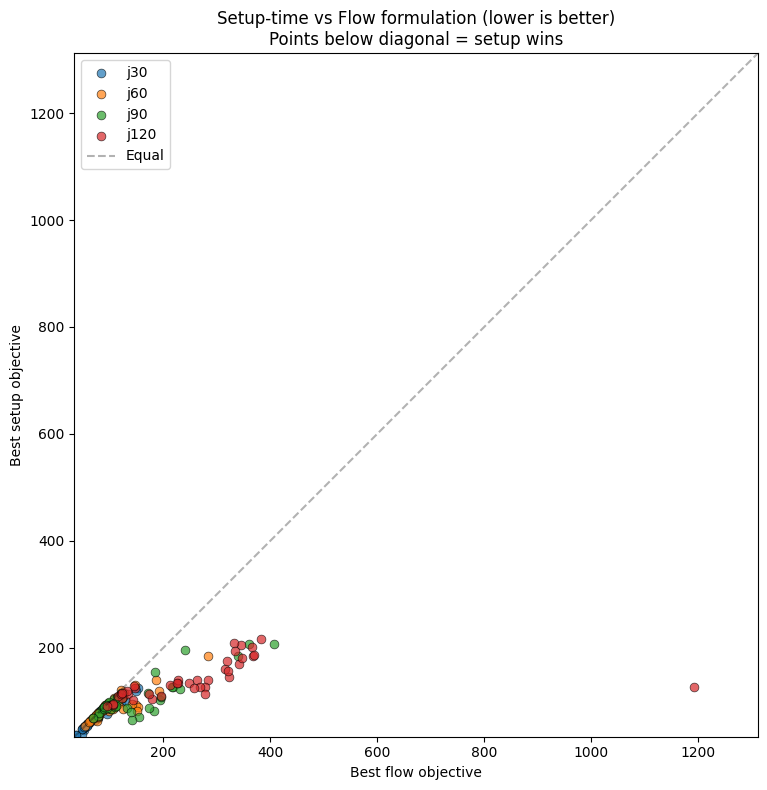

In [16]:
# Scatter: best_setup vs best_flow (colored by set)
fig, ax = plt.subplots(figsize=(8, 8))

set_colors = {"j30": "C0", "j60": "C1", "j90": "C2", "j120": "C3"}

for s in SETS:
    sb = both[both["set"] == s]
    if len(sb) > 0:
        ax.scatter(sb["best_flow"], sb["best_setup"], c=set_colors[s],
                   label=s, alpha=0.7, edgecolors="k", linewidths=0.5, s=40)

lo = min(both["best_flow"].min(), both["best_setup"].min()) * 0.9
hi = max(both["best_flow"].max(), both["best_setup"].max()) * 1.1
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, label="Equal")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Best flow objective")
ax.set_ylabel("Best setup objective")
ax.set_title("Setup-time vs Flow formulation (lower is better)\nPoints below diagonal = setup wins")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## Comparison vs Reference (Poppenborg & Knust 2016 tabu search)

For each instance we compare our **best objective across all 4 solvers** against the reference upper bound (UB) from the tabu search heuristic.

In [17]:
# Compare best_all vs ref_ub
has_ref = comp.dropna(subset=["ref_ub", "best_all"]).copy()

has_ref["vs_ref"] = "equal"
has_ref.loc[has_ref["best_all"] < has_ref["ref_ub"], "vs_ref"] = "new_best"
has_ref.loc[has_ref["best_all"] > has_ref["ref_ub"], "vs_ref"] = "worse"
has_ref.loc[has_ref["best_all"] == has_ref["ref_ub"], "vs_ref"] = "equal"

print(f"Instances with both our solution and reference UB: {len(has_ref)}")
print()

ref_summary = has_ref.groupby(["set", "vs_ref"], observed=False).size().unstack(fill_value=0)
ref_summary = ref_summary.reindex(columns=["new_best", "equal", "worse"], fill_value=0)
ref_summary.columns = ["Our best < Ref UB", "Our best = Ref UB", "Our best > Ref UB"]
ref_summary["Total"] = ref_summary.sum(axis=1)

# Also add: instances where ref exists but we found no solution
no_sol = comp[comp["ref_ub"].notna() & comp["best_all"].isna()]
no_sol_by_set = no_sol.groupby("set", observed=False).size()
ref_summary["No solution"] = no_sol_by_set.reindex(ref_summary.index, fill_value=0)

ref_summary

Instances with both our solution and reference UB: 204



,Our best < Ref UB,Our best = Ref UB,Our best > Ref UB,Total,No solution
set,,,,,
j30,5,31,12,48,0
j60,15,26,7,48,0
j90,19,17,12,48,0
j120,30,8,22,60,0


In [18]:
# Which solver produced the new best results?
new_bests = has_ref[has_ref["vs_ref"] == "new_best"].copy()
print(f"Total new best results: {len(new_bests)}")
print()

# For each new best, identify which solver(s) achieved it
for _, row in new_bests.iterrows():
    best_val = row["best_all"]
    winners = []
    for sf in solver_forms:
        if row.get(sf) is not None and row[sf] == best_val:
            winners.append(sf)
    new_bests.loc[_, "winner"] = ", ".join(winners)

print("New bests by solver:")
print(new_bests["winner"].value_counts().to_string())
print()

# Show instances where we beat reference, sorted by improvement
new_bests["improvement"] = new_bests["ref_ub"] - new_bests["best_all"]
new_bests["improvement_pct"] = (new_bests["improvement"] / new_bests["ref_ub"] * 100).round(1)

print(f"\nTop 15 improvements over reference UB:")
top = new_bests.nlargest(15, "improvement_pct")
for _, r in top.iterrows():
    print(f"  {r['instance']:15s} {r['set']:4s}  ours={int(r['best_all']):>4d}  ref_UB={int(r['ref_ub']):>4d}  "
          f"delta={int(r['improvement']):>3d} ({r['improvement_pct']:.1f}%)  by {r['winner']}")

Total new best results: 69

New bests by solver:
winner
optal_setup                    52
cpo_setup                      12
cpo_setup, optal_setup          3
cpo                             1
cpo, cpo_setup, optal_setup     1


Top 15 improvements over reference UB:
  j1208_a         j120  ours= 133  ref_UB= 145  delta= 12 (8.3%)  by optal_setup
  j12015_a        j120  ours= 133  ref_UB= 144  delta= 11 (7.6%)  by optal_setup
  j909_a          j90   ours= 185  ref_UB= 199  delta= 14 (7.0%)  by optal_setup
  j3045_a         j30   ours= 137  ref_UB= 147  delta= 10 (6.8%)  by cpo_setup
  j12049_a        j120  ours= 139  ref_UB= 149  delta= 10 (6.7%)  by optal_setup
  j9015_a         j90   ours=  70  ref_UB=  75  delta=  5 (6.7%)  by optal_setup
  j9043_a         j90   ours= 102  ref_UB= 109  delta=  7 (6.4%)  by optal_setup
  j6031_a         j60   ours=  74  ref_UB=  79  delta=  5 (6.3%)  by optal_setup
  j9030_a         j90   ours= 107  ref_UB= 114  delta=  7 (6.1%)  by optal_setup
  j904

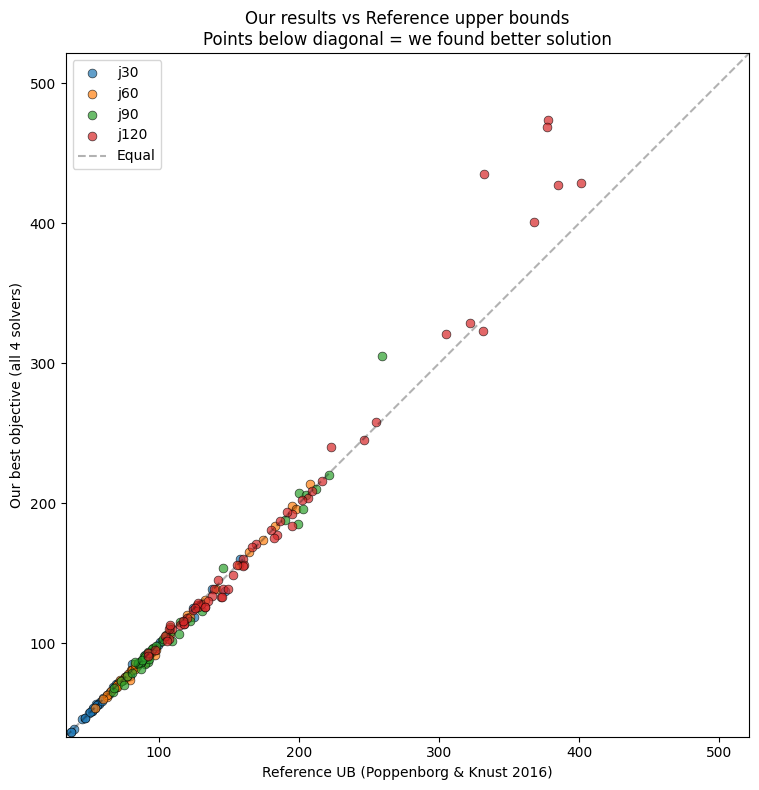

In [19]:
# Scatter: our best vs reference UB
fig, ax = plt.subplots(figsize=(8, 8))

for s in SETS:
    sb = has_ref[has_ref["set"] == s]
    if len(sb) > 0:
        ax.scatter(sb["ref_ub"], sb["best_all"], c=set_colors[s],
                   label=s, alpha=0.7, edgecolors="k", linewidths=0.5, s=40)

lo = min(has_ref["ref_ub"].min(), has_ref["best_all"].min()) * 0.9
hi = max(has_ref["ref_ub"].max(), has_ref["best_all"].max()) * 1.1
ax.plot([lo, hi], [lo, hi], "k--", alpha=0.3, label="Equal")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Reference UB (Poppenborg & Knust 2016)")
ax.set_ylabel("Our best objective (all 4 solvers)")
ax.set_title("Our results vs Reference upper bounds\nPoints below diagonal = we found better solution")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

## Optimality gap analysis

For each formulation, compute the gap between the solver's objective and the reference lower bound:
$$\text{gap} = \frac{\text{obj} - \text{LB}}{\text{LB}} \times 100\%$$

In [20]:
# Compute gaps from LB for each approach
gap_data = comp.dropna(subset=["ref_lb"]).copy()
gap_data = gap_data[gap_data["ref_lb"] > 0]

for col in ["best_flow", "best_setup", "best_all", "ref_ub"]:
    gap_data[f"gap_{col}"] = ((gap_data[col] - gap_data["ref_lb"]) / gap_data["ref_lb"] * 100).round(2)

# Average gaps by set
gap_cols = ["gap_best_flow", "gap_best_setup", "gap_best_all", "gap_ref_ub"]
gap_labels = ["Flow (best)", "Setup (best)", "All solvers (best)", "Ref UB (tabu search)"]

gap_summary = []
for s in SETS:
    sg = gap_data[gap_data["set"] == s]
    row = {"Set": s, "n": len(sg)}
    for gc, gl in zip(gap_cols, gap_labels):
        valid = sg[gc].dropna()
        row[gl] = f"{valid.mean():.1f}%" if len(valid) > 0 else "-"
    gap_summary.append(row)

gap_df = pd.DataFrame(gap_summary)
print("Average gap from lower bound (lower is better):")
print()
gap_df.style.hide(axis="index")

Average gap from lower bound (lower is better):



Set,n,Flow (best),Setup (best),All solvers (best),Ref UB (tabu search)
j30,48,39.6%,36.2%,36.2%,36.0%
j60,48,40.0%,34.8%,34.7%,35.3%
j90,48,73.0%,35.3%,35.3%,35.6%
j120,60,179.6%,91.2%,91.2%,85.9%


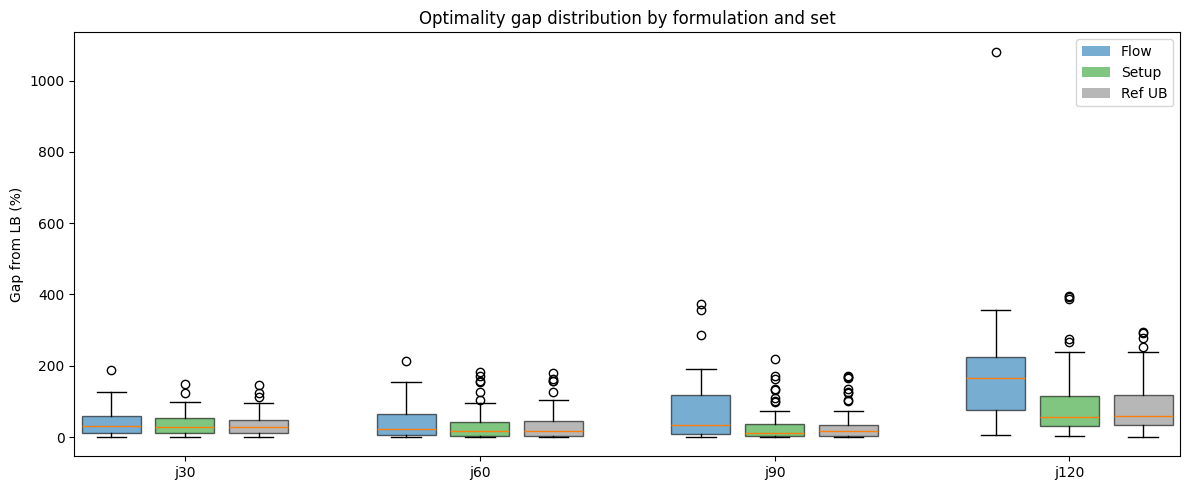

In [21]:
# Box plot of gaps by formulation and set
fig, ax = plt.subplots(figsize=(12, 5))

positions = []
data_to_plot = []
box_colors = []
box_labels = []
form_colors = {"best_flow": "#1f77b4", "best_setup": "#2ca02c", "ref_ub": "#888888"}
form_labels = {"best_flow": "Flow", "best_setup": "Setup", "ref_ub": "Ref UB"}

for j, s in enumerate(SETS):
    sg = gap_data[gap_data["set"] == s]
    for k, (gc, color) in enumerate(form_colors.items()):
        vals = sg[f"gap_{gc}"].dropna()
        if len(vals) > 0:
            data_to_plot.append(vals.values)
            positions.append(j * 4 + k)
            box_colors.append(color)

if data_to_plot:
    bp = ax.boxplot(data_to_plot, positions=positions, widths=0.8, patch_artist=True)
    for patch, color in zip(bp["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_xticks([j * 4 + 1 for j in range(len(SETS))])
    ax.set_xticklabels(SETS)
    ax.set_ylabel("Gap from LB (%)")
    ax.set_title("Optimality gap distribution by formulation and set")

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, alpha=0.6, label=l) for c, l in
                       zip(form_colors.values(), form_labels.values())]
    ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

## Grand summary

In [22]:
# Grand summary table: per set, compare all approaches
print("=" * 90)
print(f"{'Set':>5} | {'Approach':>20} | {'Solved':>7} | {'Optimal':>8} | {'Avg gap from LB':>16} | {'New bests':>10}")
print("=" * 90)

for s in SETS:
    sc = comp[comp["set"] == s]
    sg = gap_data[gap_data["set"] == s]
    n_total = len(sc)

    for sf, label in [("cpo", "CPO flow"), ("optal", "OptalCP flow"),
                       ("cpo_setup", "CPO setup"), ("optal_setup", "OptalCP setup")]:
        sub = all_df[(all_df["solver_form"] == sf) & (all_df["set"] == s)]
        n_solved = len(sub[sub["state"].isin(["Optimal", "Feasible"])])
        n_opt = len(sub[sub["state"] == "Optimal"])

        # Gap
        vals = sg[sf].dropna()
        gaps = ((vals - sg.loc[vals.index, "ref_lb"]) / sg.loc[vals.index, "ref_lb"] * 100)
        avg_gap = f"{gaps.mean():.1f}%" if len(gaps) > 0 else "-"

        # New bests vs ref
        valid = sc.dropna(subset=[sf, "ref_ub"])
        nb = (valid[sf] < valid["ref_ub"]).sum()

        print(f"{s:>5} | {label:>20} | {n_solved:>3}/{n_total:<3} | {n_opt:>4}/{n_total:<3} | {avg_gap:>16} | {nb:>10}")

    # Reference line
    ref_gaps = sg["gap_ref_ub"].dropna()
    avg_ref = f"{ref_gaps.mean():.1f}%" if len(ref_gaps) > 0 else "-"
    print(f"{s:>5} | {'Ref UB (tabu)':>20} | {'':>7} | {'':>8} | {avg_ref:>16} | {'':>10}")
    print("-" * 90)

print()
print("Key findings:")
print(f"  - Setup-time formulation finds solutions on {len(comp.dropna(subset=['best_setup']))} instances")
print(f"    vs flow formulation on {len(comp.dropna(subset=['best_flow']))} instances")
both_have = comp.dropna(subset=["best_flow", "best_setup"])
sw = (both_have["best_setup"] < both_have["best_flow"]).sum()
fw = (both_have["best_flow"] < both_have["best_setup"]).sum()
print(f"  - On {len(both_have)} shared instances: setup wins {sw}, flow wins {fw}")
n_new = len(has_ref[has_ref["vs_ref"] == "new_best"]) if len(has_ref) > 0 else 0
print(f"  - New best solutions (beating Poppenborg & Knust UB): {n_new}")

  Set |             Approach |  Solved |  Optimal |  Avg gap from LB |  New bests
  j30 |             CPO flow |  45/48  |   16/48  |            39.9% |          1
  j30 |         OptalCP flow |  20/48  |   19/48  |            11.5% |          0
  j30 |            CPO setup |  48/48  |    8/48  |            36.7% |          4
  j30 |        OptalCP setup |  48/48  |   10/48  |            39.2% |          1
  j30 |        Ref UB (tabu) |         |          |            36.0% |           
------------------------------------------------------------------------------------------
  j60 |             CPO flow |  42/48  |   12/48  |            40.3% |          1
  j60 |         OptalCP flow |  10/48  |   10/48  |             5.9% |          0
  j60 |            CPO setup |  48/48  |    9/48  |            39.8% |          6
  j60 |        OptalCP setup |  48/48  |    9/48  |            35.5% |         14
  j60 |        Ref UB (tabu) |         |          |            35.3% |           
-------